Old Messages make Summary using another LLM.
It means to old messages give to the llm and llm create the Summary of give messages(old messages)
when llm.invoke means llm call i send recant messages + summary of old messages . These process called Summarize Memory Management.

Most important Delete the old messages when Summary Generate . 
Recant Messages + Summary store in Database. 
Delete the Messages Who Summary Generate.

In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import RemoveMessage, HumanMessage  # to remove the premanant the delection messages in State
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
GOOGLE_API_KEY = os.getenv("GEMINI_API_KEY")

In [25]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    api_key=GOOGLE_API_KEY
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [26]:
class ChatState(MessagesState):
    summary: str

In [27]:
def chat_node(state: ChatState):
    messages=[]
    # adding summary + messages
    if state['summary']:
        messages.append({
            'role':'system',
            'content':f"Conservation summary:\n{state['summary']}"
        })
    # final message
    messages.extend(state['messages'])
    print(messages)
    # give to the llm final message
    response = model.invoke(messages)
    return{"messages":[response]}

Perform Summary + Perform Delection

In [29]:
def summarize_conservation(state: ChatState):
    existing_summary = state["summary"]

    if existing_summary:
        prompt = f"Update this summary with new conversation, keep it concise:\n{existing_summary}"
    else:
        prompt = "Summarize the conversation briefly with key points."

    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]
    response = model.invoke(messages_for_summary)

    # keep only last 2 messages
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [30]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [31]:
builder = StateGraph(ChatState)

builder.add_node("Chat",chat_node)
builder.add_node("summarize",summarize_conservation)

builder.add_edge(START,"Chat")
builder.add_conditional_edges(
    "Chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)
builder.add_edge("summarize", "__end__")



In [32]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

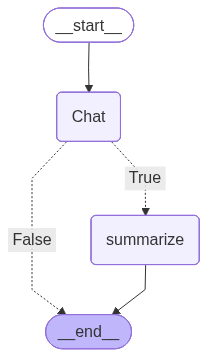

In [33]:
graph

In [34]:
config = {
    'configurable':{'thread_id':'chat-2'}
}


In [35]:
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n----STATE-----")
    print("summary",vals.get("summary",""))
    print("run_messages:", len(vals.get("messages",[])))
    print("messages:")
    for m in vals.get("messages",[]):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
out = graph.invoke({"messages":[HumanMessage(content='quantum Physics')], 'summary':''}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='6c951f28-8271-4cde-b600-08b2cdf0d096')]
{'messages': [HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='6c951f28-8271-4cde-b600-08b2cdf0d096'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of physics that deals with the behavior of matter and energy at the most fundamental level—the scale of atoms and subatomic particles (like electrons, protons, and photons).\n\nAt this tiny scale, the "common sense" laws of classical physics (the world we see around us) break down and are replaced by rules that seem bizarre and counterintuitive.\n\nHere are the key concepts of quantum physics explained simply:\n\n---\n\n### 1. Quanta (The "Chunks" of Energy)\nIn our everyday world, energy seems continuous. For example, you can turn a dimmer switch and smoothly increase light. However, in the quantum world, energy

In [36]:
out = graph.invoke({"messages":[HumanMessage(content='how is Albert Einstien related?')], 'summary':''}, config=config)
print(out)
show_state()

[HumanMessage(content='how is Albert Einstien related?', additional_kwargs={}, response_metadata={}, id='14a29172-8b1b-4622-aa32-3d447e546c42')]


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 45.885304111s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
out = graph.invoke({"messages":[HumanMessage(content='What are some of Einstien Famous work.')], 'summary':''}, config=config)
print(out)
show_state()

In [ ]:
out = graph.invoke({"messages":[HumanMessage(content='Explain special theory of relativity.')], 'summary':''}, config=config)
print(out)
show_state()